<a href="https://colab.research.google.com/github/Mohammed-Taher6705/jigsaw-puzzle-matching/blob/main/Try_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found tiles: ['/content/Try_1/0_r1_c0.jpg', '/content/Try_1/0_r0_c1.jpg', '/content/Try_1/0_r1_c1.jpg', '/content/Try_1/0_r0_c0.jpg']


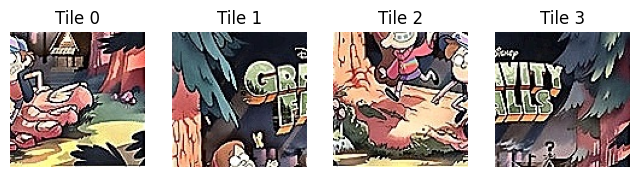

Best solution found with total score: 0.001
Solved order (TL, TR, BL, BR): [1, 3, 2, 0]


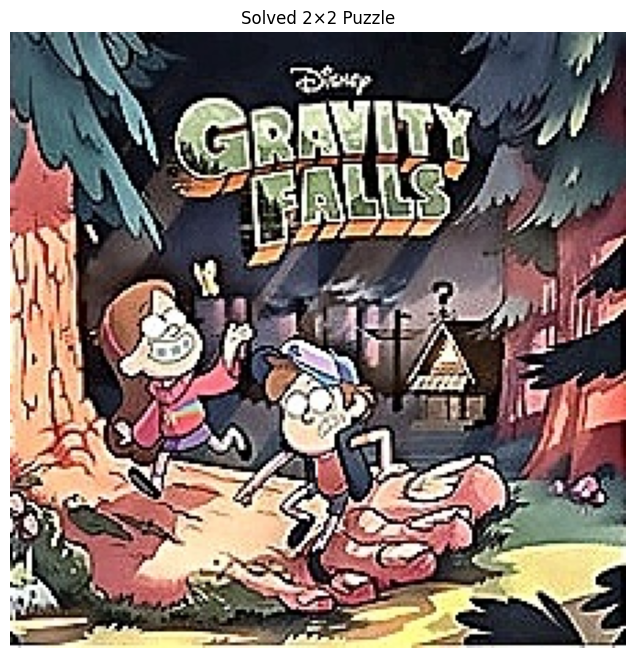

In [ ]:
import cv2
import numpy as np
import glob
import itertools
import matplotlib.pyplot as plt

# ===========================================
# 1. Load exactly 4 tiles from TRY_PICS folder
# ===========================================
tiles_folder = "/content/Try_2/"

tile_paths = []
for ext in ["*.png", "*.PNG", "*.jpg", "*.JPG", "*.jpeg", "*.JPEG"]:
    tile_paths += glob.glob(tiles_folder + ext)

print("Found tiles:", tile_paths)
assert len(tile_paths) == 4, f"Expected 4 tiles, found {len(tile_paths)}"

tiles = [cv2.imread(p) for p in tile_paths]

# Show loaded tiles
plt.figure(figsize=(8, 4))
for i, t in enumerate(tiles):
    plt.subplot(1, 4, i+1)
    plt.imshow(cv2.cvtColor(t, cv2.COLOR_BGR2RGB))
    plt.title(f"Tile {i}")
    plt.axis('off')
plt.show()

# ===========================================
# 2. Extract the 4 RGB edge strips of each tile
# ===========================================
def get_edges(tile, band=50):
    h, w = tile.shape[:2]
    top = tile[0:band, :]
    bottom = tile[h-band:h, :]
    left = tile[:, 0:band]
    right = tile[:, w-band:w]
    return [top, bottom, left, right]

# ===========================================
# 3. RGB descriptor (average colors)
# ===========================================
def rgb_descriptor(edge):
    edge = cv2.resize(edge, (200, 50))  # Keep resizing for consistency

    B, G, R = cv2.split(edge)

    # Compute average R, G, B per channel
    avg_R = np.mean(R)
    avg_G = np.mean(G)
    avg_B = np.mean(B)

    desc = np.array([avg_R, avg_G, avg_B], dtype=np.float64)
    desc /= np.linalg.norm(desc) + 1e-6  # Normalize
    return desc

# ===========================================
# 4. Build descriptors for all tile edges (NO rotations)
# ===========================================
edges = []
descriptors = []

for tile_idx, tile in enumerate(tiles):
    # Get edges (no rotation)
    e = get_edges(tile)
    d = [rgb_descriptor(x) for x in e]
    edges.append(e)
    descriptors.append(d)

# ===========================================
# 5. Compute all edge-to-edge scores using cosine similarity
# ===========================================
scores = np.full((4, 4, 4, 4), np.inf)  # tileA, edgeA, tileB, edgeB

for A in range(4):
    for eA in range(4):
        for B in range(4):
            if A == B: continue
            for eB in range(4):
                dA = descriptors[A][eA]
                dB = descriptors[B][eB]

                # Cosine similarity: 1 - dot product (lower is better match)
                similarity = np.dot(dA, dB)
                dist1 = 1 - similarity

                # Reversed comparison
                dist2 = 1 - np.dot(dA, dB[::-1])

                scores[A, eA, B, eB] = min(dist1, dist2)

# ===========================================
# 6. Brute-force solver for 2×2 (NO rotations)
# ===========================================
def brute_force_solve(threshold=0.1):
    best_solution = None
    best_score = np.inf

    for perm in itertools.permutations([0, 1, 2, 3]):  # All tile orders
        # No rotations to consider
        arr = [(tile, 0) for tile in perm]  # Keeping format for compatibility

        # Check if valid (all edge matches below threshold)
        valid = True
        total_score = 0
        checks = [
            (arr[0], 3, arr[1], 2),  # TL.right vs TR.left
            (arr[0], 1, arr[2], 0),  # TL.bottom vs BL.top
            (arr[1], 1, arr[3], 0),  # TR.bottom vs BR.top
            (arr[2], 3, arr[3], 2),  # BL.right vs BR.left
        ]
        for tileA_rotA, edgeA, tileB_rotB, edgeB in checks:
            tileA, _ = tileA_rotA  # Ignore rotation
            tileB, _ = tileB_rotB  # Ignore rotation
            score = scores[tileA, edgeA, tileB, edgeB]
            if score > threshold:
                valid = False
                break
            total_score += score

        if valid and total_score < best_score:
            best_score = total_score
            best_solution = {i: (perm[i], 0) for i in range(4)}  # pos -> (tile, 0)

    if best_solution is None:
        print("No valid arrangement found. Check images or lower threshold.")
    else:
        print(f"Best solution found with total score: {best_score:.3f}")

    return best_solution

solution = brute_force_solve()

# ===========================================
# 7. Assemble and show final puzzle (NO rotations)
# ===========================================
if solution is None:
    print("⚠ No match found. Check images or lower threshold.")
else:
    TL, TR, BL, BR = solution[0], solution[1], solution[2], solution[3]
    print("Solved order (TL, TR, BL, BR):", [TL[0], TR[0], BL[0], BR[0]])

    # Direct assembly (no rotations)
    top_row = np.hstack([tiles[TL[0]], tiles[TR[0]]])
    bottom_row = np.hstack([tiles[BL[0]], tiles[BR[0]]])
    final = np.vstack([top_row, bottom_row])

    # Show final puzzle
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
    plt.title("Solved 2×2 Puzzle")
    plt.axis('off')
    plt.show()

Solving jigsaw puzzle
Found 4 tiles: ['25_r0_c0.jpg', '25_r1_c1.jpg', '25_r0_c1.jpg', '25_r1_c0.jpg']
Solving puzzle with 4 tiles
  Tile 0: (112, 112, 3), band size: 20
  Tile 1: (112, 112, 3), band size: 20
  Tile 2: (112, 112, 3), band size: 20
  Tile 3: (112, 112, 3), band size: 20
Average edge band size: 20.0 pixels
Adaptive threshold: 0.1145
✅ Solution: (3, 2, 1, 0) (score: 0.2564)


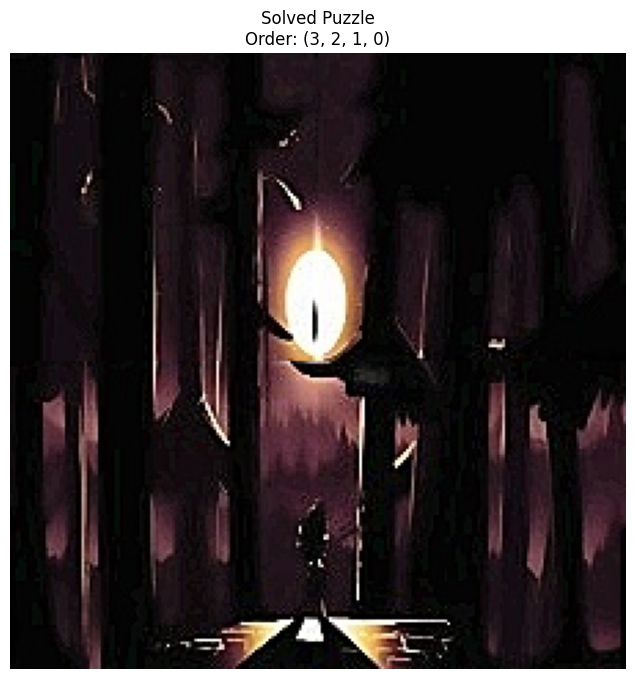

✅ Puzzle solved successfully!


In [ ]:
import cv2
import numpy as np
import glob
import itertools
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ===========================================
# 1. Load tiles
# ===========================================
def load_tiles(folder_path):
    tile_paths = []
    for ext in ["*.png", "*.PNG", "*.jpg", "*.JPG", "*.jpeg", "*.JPEG"]:
        tile_paths += glob.glob(folder_path + ext)

    print(f"Found {len(tile_paths)} tiles: {[p.split('/')[-1] for p in tile_paths]}")
    if len(tile_paths) != 4:
        print(f"⚠ Warning: Expected 4 tiles, found {len(tile_paths)}")
        if len(tile_paths) < 4:
            print("❌ Not enough tiles to solve puzzle")
            return [], []

    tiles = [cv2.imread(p) for p in tile_paths]
    return tiles, tile_paths

# ===========================================
# 2. Adaptive edge extraction
# ===========================================
def get_adaptive_edges(tile):
    h, w = tile.shape[:2]

    # Adaptive band size (10% of smaller dimension, but min 20px, max 100px)
    band_size = max(20, min(100, int(min(h, w) * 0.1)))

    top = tile[0:band_size, :]
    bottom = tile[h-band_size:h, :]
    left = tile[:, 0:band_size]
    right = tile[:, w-band_size:w]

    return [top, bottom, left, right], band_size

# ===========================================
# 3. Enhanced descriptor with multiple features
# ===========================================
def enhanced_descriptor(edge):
    # Resize to fixed size for consistency
    edge_resized = cv2.resize(edge, (100, 100))

    # 1. Color features (average in multiple color spaces)
    avg_bgr = np.mean(edge_resized, axis=(0, 1))

    hsv = cv2.cvtColor(edge_resized, cv2.COLOR_BGR2HSV)
    avg_hsv = np.mean(hsv, axis=(0, 1))

    lab = cv2.cvtColor(edge_resized, cv2.COLOR_BGR2LAB)
    avg_lab = np.mean(lab, axis=(0, 1))

    # 2. Texture features (gradients)
    gray = cv2.cvtColor(edge_resized, cv2.COLOR_BGR2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.mean(np.sqrt(sobelx**2 + sobely**2))
    gradient_direction = np.mean(np.arctan2(sobely, sobelx + 1e-6))

    # 3. Edge intensity (Canny)
    edges_canny = cv2.Canny(gray, 100, 200)
    edge_density = np.mean(edges_canny) / 255.0

    # 4. Color histogram features (simplified)
    hist_h = cv2.calcHist([hsv], [0], None, [8], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [8], [0, 256]).flatten()
    hist_h = hist_h / (np.sum(hist_h) + 1e-6)
    hist_s = hist_s / (np.sum(hist_s) + 1e-6)

    # Combine all features
    features = np.concatenate([
        avg_bgr / 255.0,
        avg_hsv / np.array([180.0, 256.0, 256.0]),
        avg_lab / np.array([100.0, 256.0, 256.0]),
        [gradient_magnitude / 1000.0, gradient_direction / np.pi],
        [edge_density],
        hist_h,
        hist_s
    ])

    # Normalize
    features = features / (np.linalg.norm(features) + 1e-6)
    return features

# ===========================================
# 4. Calculate compatibility scores
# ===========================================
def calculate_compatibility_scores(descriptors):
    n_tiles = len(descriptors)
    scores = np.full((n_tiles, 4, n_tiles, 4), np.inf)  # tileA, edgeA, tileB, edgeB

    for A in range(n_tiles):
        for eA in range(4):
            for B in range(n_tiles):
                if A == B:
                    continue
                for eB in range(4):
                    dA = descriptors[A][eA]
                    dB = descriptors[B][eB]

                    # Multiple distance metrics
                    cos_dist = 1.0 - np.dot(dA, dB)
                    l2_dist = np.linalg.norm(dA - dB)

                    # Combined score (weighted)
                    score = 0.7 * cos_dist + 0.3 * l2_dist
                    scores[A, eA, B, eB] = score

    return scores

# ===========================================
# 5. Smart puzzle solver
# ===========================================
def solve_puzzle(tiles, adaptive_threshold=True):
    n_tiles = len(tiles)
    if n_tiles != 4:
        print(f"❌ Need exactly 4 tiles, got {n_tiles}")
        return None, np.inf, []

    print(f"Solving puzzle with {n_tiles} tiles")

    # Extract edges and descriptors
    edges_list = []
    descriptors_list = []
    band_sizes = []

    for i, tile in enumerate(tiles):
        edges, band_size = get_adaptive_edges(tile)
        descriptors = [enhanced_descriptor(e) for e in edges]
        edges_list.append(edges)
        descriptors_list.append(descriptors)
        band_sizes.append(band_size)
        print(f"  Tile {i}: {tile.shape}, band size: {band_size}")

    avg_band_size = np.mean(band_sizes)
    print(f"Average edge band size: {avg_band_size:.1f} pixels")

    # Calculate compatibility scores
    scores = calculate_compatibility_scores(descriptors_list)

    # Adaptive threshold based on scores distribution
    if adaptive_threshold:
        all_scores = scores[scores < np.inf]
        if len(all_scores) > 0:
            threshold = np.percentile(all_scores, 30)  # 30th percentile
            print(f"Adaptive threshold: {threshold:.4f}")
        else:
            threshold = 0.2
            print(f"Using default threshold: {threshold:.4f}")
    else:
        threshold = 0.2

    # Brute force search
    best_solution = None
    best_score = np.inf

    for perm in itertools.permutations(range(n_tiles)):
        total_score = 0
        valid = True

        # Define edge matches for 2x2 grid
        matches = [
            (perm[0], 3, perm[1], 2),  # TL.right ↔ TR.left
            (perm[0], 1, perm[2], 0),  # TL.bottom ↔ BL.top
            (perm[1], 1, perm[3], 0),  # TR.bottom ↔ BR.top
            (perm[2], 3, perm[3], 2),  # BL.right ↔ BR.left
        ]

        for tileA, edgeA, tileB, edgeB in matches:
            score = scores[tileA, edgeA, tileB, edgeB]
            if score > threshold * 2.0:  # Higher tolerance for individual edges
                valid = False
                break
            total_score += score

        if valid and total_score < best_score:
            best_score = total_score
            best_solution = perm

    if best_solution is None:
        print("⚠ No valid solution found with current threshold")
        # Try finding best match regardless of threshold
        for perm in itertools.permutations(range(n_tiles)):
            total_score = 0
            matches = [
                (perm[0], 3, perm[1], 2),
                (perm[0], 1, perm[2], 0),
                (perm[1], 1, perm[3], 0),
                (perm[2], 3, perm[3], 2),
            ]

            for tileA, edgeA, tileB, edgeB in matches:
                total_score += scores[tileA, edgeA, tileB, edgeB]

            if total_score < best_score:
                best_score = total_score
                best_solution = perm

        if best_solution is not None:
            print(f"Found best solution (ignoring threshold) with score: {best_score:.4f}")

    return best_solution, best_score, edges_list

# ===========================================
# 6. Visualization (FIXED VERSION)
# ===========================================
def visualize_solution(tiles, solution, edges_list):
    if solution is None:
        print("❌ No valid solution found!")
        return None

    print(f"✅ Solution found! Tile order: {solution}")

    # Create a single figure for the solution
    fig = plt.figure(figsize=(15, 10))

    # 1. Show individual tiles
    for i, tile_idx in enumerate(solution):
        plt.subplot(3, 4, i+1)
        plt.imshow(cv2.cvtColor(tiles[tile_idx], cv2.COLOR_BGR2RGB))
        plt.title(f"Tile {tile_idx} → Pos {['TL', 'TR', 'BL', 'BR'][i]}")
        plt.axis('off')

    # 2. Show edges for each tile (top and bottom only)
    for i, tile_idx in enumerate(solution):
        edges = edges_list[tile_idx]
        # Show top edge
        plt.subplot(3, 4, 5 + i)
        plt.imshow(cv2.cvtColor(edges[0], cv2.COLOR_BGR2RGB))
        plt.title(f"Tile {tile_idx} - Top edge")
        plt.axis('off')

        # Show bottom edge
        plt.subplot(3, 4, 9 + i)
        plt.imshow(cv2.cvtColor(edges[1], cv2.COLOR_BGR2RGB))
        plt.title(f"Tile {tile_idx} - Bottom edge")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 3. Assemble final puzzle
    positions = ['TL', 'TR', 'BL', 'BR']
    tile_map = {positions[i]: tiles[solution[i]] for i in range(4)}

    # Ensure all tiles have same dimensions
    heights = [t.shape[0] for t in tile_map.values()]
    widths = [t.shape[1] for t in tile_map.values()]

    # Resize if needed (use smallest dimensions)
    if len(set(heights)) > 1 or len(set(widths)) > 1:
        print("⚠ Tiles have different sizes, resizing...")
        target_h, target_w = min(heights), min(widths)
        for pos in tile_map:
            tile_map[pos] = cv2.resize(tile_map[pos], (target_w, target_h))

    # Assemble
    top_row = np.hstack([tile_map['TL'], tile_map['TR']])
    bottom_row = np.hstack([tile_map['BL'], tile_map['BR']])
    final = np.vstack([top_row, bottom_row])

    # Show final puzzle
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
    plt.title(f"Solved 2×2 Puzzle\nTile order: {solution}")
    plt.axis('off')
    plt.show()

    return final

# ===========================================
# 7. Main execution
# ===========================================
def solve_jigsaw_puzzle(folder_path):
    # Load tiles
    tiles, paths = load_tiles(folder_path)

    if len(tiles) != 4:
        print(f"❌ Need exactly 4 tiles, got {len(tiles)}")
        return None

    # Display loaded tiles
    plt.figure(figsize=(12, 3))
    for i, (tile, path) in enumerate(zip(tiles, paths)):
        plt.subplot(1, 4, i+1)
        plt.imshow(cv2.cvtColor(tile, cv2.COLOR_BGR2RGB))
        plt.title(f"Tile {i}\n{path.split('/')[-1][:20]}...")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Solve puzzle
    solution, score, edges_list = solve_puzzle(tiles, adaptive_threshold=True)

    if solution is not None:
        print(f"🏆 Best solution score: {score:.4f}")
        final = visualize_solution(tiles, solution, edges_list)
        return final
    else:
        print("❌ Failed to find a solution.")
        return None

# ===========================================
# 8. Simple test function (no visualization errors)
# ===========================================
def simple_solve_puzzle(folder_path):
    """Simplified version without complex visualization"""
    # Load tiles
    tiles, paths = load_tiles(folder_path)

    if len(tiles) != 4:
        print(f"❌ Need exactly 4 tiles, got {len(tiles)}")
        return None

    # Solve puzzle
    solution, score, _ = solve_puzzle(tiles, adaptive_threshold=True)

    if solution is None:
        print("❌ No solution found")
        return None

    print(f"✅ Solution: {solution} (score: {score:.4f})")

    # Simple assembly
    positions = ['TL', 'TR', 'BL', 'BR']
    tile_map = {positions[i]: tiles[solution[i]] for i in range(4)}

    # Resize to smallest dimensions
    heights = [t.shape[0] for t in tile_map.values()]
    widths = [t.shape[1] for t in tile_map.values()]
    target_h, target_w = min(heights), min(widths)

    for pos in tile_map:
        tile_map[pos] = cv2.resize(tile_map[pos], (target_w, target_h))

    # Assemble and show
    top_row = np.hstack([tile_map['TL'], tile_map['TR']])
    bottom_row = np.hstack([tile_map['BL'], tile_map['BR']])
    final = np.vstack([top_row, bottom_row])

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
    plt.title(f"Solved Puzzle\nOrder: {solution}")
    plt.axis('off')
    plt.show()

    return final

# ===========================================
# 9. Run the solver
# ===========================================
if __name__ == "__main__":
    folder_path = "/content/Try_5/"  # Change this to your folder

    print("=" * 60)
    print("Solving jigsaw puzzle")
    print("=" * 60)

    # Use the simple version to avoid visualization errors
    solved_puzzle = simple_solve_puzzle(folder_path)

    if solved_puzzle is not None:
        print("✅ Puzzle solved successfully!")
    else:
        print("❌ Failed to solve puzzle")

In [ ]:
!git clone https://github.com/Mohammed-Taher6705/jigsaw-puzzle-matching.git

Cloning into 'jigsaw-puzzle-matching'...
remote: Enumerating objects: 1252, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 1252 (delta 25), reused 23 (delta 17), pack-reused 1206 (from 2)
Receiving objects: 100% (1252/1252), 180.77 MiB | 22.56 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/jigsaw-puzzle-matching/Task3_output.zip"
extract_path = "/content/Task3_output"


os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)
print("Contents:", os.listdir(extract_path))

Extracted to: /content/Task3_output
Contents: ['puzzle_4x4', 'puzzle_8x8', 'puzzle_2x2']


In [ ]:
import cv2
import numpy as np
import glob
import itertools
import matplotlib.pyplot as plt
import os
import time

# ===========================================
# 1. Load ALL tiles from folder
# ===========================================
def load_all_tiles(folder_path):
    """Load all image tiles from folder"""
    tile_paths = []
    for ext in ["*.png", "*.PNG", "*.jpg", "*.JPG", "*.jpeg", "*.JPEG"]:
        tile_paths += glob.glob(os.path.join(folder_path, ext))

    tile_paths.sort()
    print(f"Found {len(tile_paths)} total tiles in folder")

    tiles = []
    valid_paths = []
    for p in tile_paths:
        img = cv2.imread(p)
        if img is not None:
            # Resize to standard size for consistency
            img = cv2.resize(img, (200, 200))
            tiles.append(img)
            valid_paths.append(p)

    return tiles, valid_paths

# ===========================================
# 2. Group tiles into 2×2 puzzles (4 tiles each)
# ===========================================
def group_into_2x2_puzzles(tiles, paths):
    """Group tiles into 2×2 puzzles (4 tiles each)"""
    total_tiles = len(tiles)
    puzzle_size = 4  # 2×2

    print(f"\nGrouping tiles into 2×2 puzzles (4 tiles each)...")

    if total_tiles < puzzle_size:
        print(f"❌ Not enough tiles for any 2×2 puzzle")
        return [], []

    num_puzzles = total_tiles // puzzle_size
    puzzles = []
    puzzle_paths = []

    for i in range(num_puzzles):
        start_idx = i * puzzle_size
        end_idx = (i + 1) * puzzle_size
        puzzle_tiles = tiles[start_idx:end_idx]
        puzzle_paths_list = paths[start_idx:end_idx]

        puzzles.append(puzzle_tiles)
        puzzle_paths.append(puzzle_paths_list)
        print(f"  Puzzle {i+1}: Tiles {start_idx} to {end_idx-1}")

    return puzzles, puzzle_paths

# ===========================================
# 3. COMMON UTILITY FUNCTIONS
# ===========================================
def visualize_2x2_solution(tiles, arrangement, puzzle_num, score, algorithm_name):
    """Visualize a 2×2 solution"""
    positions = ['TL', 'TR', 'BL', 'BR']
    tile_map = {positions[i]: tiles[arrangement[i]] for i in range(4)}

    # Resize to same dimensions
    heights = [t.shape[0] for t in tile_map.values()]
    widths = [t.shape[1] for t in tile_map.values()]
    target_h, target_w = min(heights), min(widths)

    for pos in tile_map:
        tile_map[pos] = cv2.resize(tile_map[pos], (target_w, target_h))

    # Assemble
    top_row = np.hstack([tile_map['TL'], tile_map['TR']])
    bottom_row = np.hstack([tile_map['BL'], tile_map['BR']])
    final = np.vstack([top_row, bottom_row])

    return final

# ===========================================
# 4. ALGORITHM 1: ORIGINAL COMPLEX DESCRIPTOR
# ===========================================
def algorithm1_original_complex(tiles):
    """Original algorithm with complex descriptor"""
    print("  🧠 Algorithm 1: Original Complex Descriptor")

    def get_adaptive_edges(tile):
        h, w = tile.shape[:2]
        band_size = max(20, min(100, int(min(h, w) * 0.1)))

        top = tile[0:band_size, :]
        bottom = tile[h-band_size:h, :]
        left = tile[:, 0:band_size]
        right = tile[:, w-band_size:w]

        return [top, bottom, left, right], band_size

    def enhanced_descriptor(edge):
        edge_resized = cv2.resize(edge, (100, 100))

        avg_bgr = np.mean(edge_resized, axis=(0, 1))
        hsv = cv2.cvtColor(edge_resized, cv2.COLOR_BGR2HSV)
        avg_hsv = np.mean(hsv, axis=(0, 1))
        lab = cv2.cvtColor(edge_resized, cv2.COLOR_BGR2LAB)
        avg_lab = np.mean(lab, axis=(0, 1))

        gray = cv2.cvtColor(edge_resized, cv2.COLOR_BGR2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.mean(np.sqrt(sobelx**2 + sobely**2))
        gradient_direction = np.mean(np.arctan2(sobely, sobelx + 1e-6))

        edges_canny = cv2.Canny(gray, 100, 200)
        edge_density = np.mean(edges_canny) / 255.0

        hist_h = cv2.calcHist([hsv], [0], None, [8], [0, 180]).flatten()
        hist_s = cv2.calcHist([hsv], [1], None, [8], [0, 256]).flatten()
        hist_h = hist_h / (np.sum(hist_h) + 1e-6)
        hist_s = hist_s / (np.sum(hist_s) + 1e-6)

        features = np.concatenate([
            avg_bgr / 255.0,
            avg_hsv / np.array([180.0, 256.0, 256.0]),
            avg_lab / np.array([100.0, 256.0, 256.0]),
            [gradient_magnitude / 1000.0, gradient_direction / np.pi],
            [edge_density],
            hist_h,
            hist_s
        ])

        features = features / (np.linalg.norm(features) + 1e-6)
        return features

    # Extract edges and descriptors
    descriptors_list = []

    for tile in tiles:
        edges, _ = get_adaptive_edges(tile)
        descriptors = [enhanced_descriptor(e) for e in edges]
        descriptors_list.append(descriptors)

    # Calculate compatibility scores
    n_tiles = 4
    scores = np.full((n_tiles, 4, n_tiles, 4), np.inf)

    for A in range(n_tiles):
        for eA in range(4):
            for B in range(n_tiles):
                if A == B:
                    continue
                for eB in range(4):
                    dA = descriptors_list[A][eA]
                    dB = descriptors_list[B][eB]
                    cos_dist = 1.0 - np.dot(dA, dB)
                    l2_dist = np.linalg.norm(dA - dB)
                    score = 0.7 * cos_dist + 0.3 * l2_dist
                    scores[A, eA, B, eB] = score

    # Brute force search
    best_solution = None
    best_score = np.inf

    for perm in itertools.permutations(range(4)):
        total_score = 0
        valid = True

        matches = [
            (perm[0], 3, perm[1], 2),
            (perm[0], 1, perm[2], 0),
            (perm[1], 1, perm[3], 0),
            (perm[2], 3, perm[3], 2),
        ]

        for tileA, edgeA, tileB, edgeB in matches:
            score = scores[tileA, edgeA, tileB, edgeB]
            if score > 0.5:  # Fixed threshold
                valid = False
                break
            total_score += score

        if valid and total_score < best_score:
            best_score = total_score
            best_solution = perm

    return best_solution, best_score

# ===========================================
# 5. ALGORITHM 2: SIMPLE COLOR-BASED
# ===========================================
def algorithm2_simple_color(tiles):
    """Simple algorithm using only color features"""
    print("  🎨 Algorithm 2: Simple Color-Based")

    def get_edge_features(tile, side):
        h, w = tile.shape[:2]
        band_size = 30

        if side == 0:  # Top
            edge = tile[0:band_size, :]
        elif side == 1:  # Bottom
            edge = tile[h-band_size:h, :]
        elif side == 2:  # Left
            edge = tile[:, 0:band_size]
        else:  # Right
            edge = tile[:, w-band_size:w]

        # Simple average color
        avg_color = np.mean(edge, axis=(0, 1))
        return avg_color / 255.0  # Normalize

    # Calculate all edge features
    edge_features = []
    for i, tile in enumerate(tiles):
        features = [get_edge_features(tile, side) for side in range(4)]
        edge_features.append(features)

    # Brute force search with simple Euclidean distance
    best_solution = None
    best_score = np.inf

    for perm in itertools.permutations(range(4)):
        total_score = 0

        matches = [
            (perm[0], 3, perm[1], 2),  # TL.right ↔ TR.left
            (perm[0], 1, perm[2], 0),  # TL.bottom ↔ BL.top
            (perm[1], 1, perm[3], 0),  # TR.bottom ↔ BR.top
            (perm[2], 3, perm[3], 2),  # BL.right ↔ BR.left
        ]

        for tileA, edgeA, tileB, edgeB in matches:
            featA = edge_features[tileA][edgeA]
            featB = edge_features[tileB][edgeB]
            score = np.linalg.norm(featA - featB)
            total_score += score

        if total_score < best_score:
            best_score = total_score
            best_solution = perm

    return best_solution, best_score

# ===========================================
# 6. ALGORITHM 3: GRADIENT-BASED
# ===========================================
def algorithm3_gradient_based(tiles):
    """Algorithm focusing on gradient/texture features"""
    print("  🌊 Algorithm 3: Gradient-Based")

    def get_gradient_features(tile, side):
        h, w = tile.shape[:2]
        band_size = 40  # Larger band for gradients

        if side == 0:  # Top
            edge = tile[0:band_size, :]
        elif side == 1:  # Bottom
            edge = tile[h-band_size:h, :]
        elif side == 2:  # Left
            edge = tile[:, 0:band_size]
        else:  # Right
            edge = tile[:, w-band_size:w]

        # Resize for consistency
        edge_resized = cv2.resize(edge, (100, 100))
        gray = cv2.cvtColor(edge_resized, cv2.COLOR_BGR2GRAY)

        # Calculate gradients
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

        gradient_magnitude = np.mean(np.sqrt(sobelx**2 + sobely**2))
        gradient_direction = np.mean(np.arctan2(sobely, sobelx + 1e-6))

        # Edge density
        edges_canny = cv2.Canny(gray, 100, 200)
        edge_density = np.mean(edges_canny) / 255.0

        return np.array([gradient_magnitude / 1000.0,
                        gradient_direction / np.pi,
                        edge_density])

    # Calculate all gradient features
    gradient_features = []
    for i, tile in enumerate(tiles):
        features = [get_gradient_features(tile, side) for side in range(4)]
        gradient_features.append(features)

    # Brute force search
    best_solution = None
    best_score = np.inf

    for perm in itertools.permutations(range(4)):
        total_score = 0

        matches = [
            (perm[0], 3, perm[1], 2),
            (perm[0], 1, perm[2], 0),
            (perm[1], 1, perm[3], 0),
            (perm[2], 3, perm[3], 2),
        ]

        for tileA, edgeA, tileB, edgeB in matches:
            featA = gradient_features[tileA][edgeA]
            featB = gradient_features[tileB][edgeB]
            score = np.linalg.norm(featA - featB)
            total_score += score

        if total_score < best_score:
            best_score = total_score
            best_solution = perm

    return best_solution, best_score

# ===========================================
# 7. ALGORITHM 4: CORNER-BASED MATCHING
# ===========================================
def algorithm4_corner_based(tiles):
    """Algorithm focusing on corner compatibility"""
    print("  ⚙️ Algorithm 4: Corner-Based Matching")

    def get_corner_features(tile):
        """Get features from all corners of a tile"""
        h, w = tile.shape[:2]
        corner_size = 50

        # Extract corner regions
        top_left = tile[0:corner_size, 0:corner_size]
        top_right = tile[0:corner_size, w-corner_size:w]
        bottom_left = tile[h-corner_size:h, 0:corner_size]
        bottom_right = tile[h-corner_size:h, w-corner_size:w]

        corners = [top_left, top_right, bottom_left, bottom_right]

        # Simple color features for each corner
        features = []
        for corner in corners:
            avg_color = np.mean(corner, axis=(0, 1)) / 255.0
            features.append(avg_color)

        return features

    # Get corner features for all tiles
    corner_features = []
    for tile in tiles:
        features = get_corner_features(tile)
        corner_features.append(features)

    # Find best arrangement based on corner matching
    best_solution = None
    best_score = np.inf

    for perm in itertools.permutations(range(4)):
        # For 2x2 grid, corners should match:
        # TL.bottom-right ↔ BL.top-right
        # TL.bottom-left ↔ TR.top-left
        # TR.bottom-right ↔ BR.top-left
        # BL.bottom-right ↔ BR.top-right

        total_score = 0

        # TL with TR (right edge)
        tl_tr_score = np.linalg.norm(
            corner_features[perm[0]][1] -  # TL top-right
            corner_features[perm[1]][0]    # TR top-left
        )

        # TL with BL (bottom edge)
        tl_bl_score = np.linalg.norm(
            corner_features[perm[0]][2] -  # TL bottom-left
            corner_features[perm[2]][0]    # BL top-left
        )

        # TR with BR (bottom edge)
        tr_br_score = np.linalg.norm(
            corner_features[perm[1]][3] -  # TR bottom-right
            corner_features[perm[3]][1]    # BR top-right
        )

        # BL with BR (right edge)
        bl_br_score = np.linalg.norm(
            corner_features[perm[2]][3] -  # BL bottom-right
            corner_features[perm[3]][2]    # BR bottom-left
        )

        total_score = tl_tr_score + tl_bl_score + tr_br_score + bl_br_score

        if total_score < best_score:
            best_score = total_score
            best_solution = perm

    return best_solution, best_score

# ===========================================
# 8. TEST ALL ALGORITHMS ON EACH 2×2 PUZZLE
# ===========================================
def test_all_algorithms_on_puzzle(puzzle_tiles, puzzle_num):
    """Test all 4 algorithms on a single 2×2 puzzle"""
    print(f"\n{'='*60}")
    print(f"TESTING ALL ALGORITHMS ON PUZZLE #{puzzle_num}")
    print(f"{'='*60}")

    # Display the puzzle tiles
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i, tile in enumerate(puzzle_tiles):
        axes[i].imshow(cv2.cvtColor(tile, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Tile {i}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

    results = []

    # Test Algorithm 1
    start_time = time.time()
    sol1, score1 = algorithm1_original_complex(puzzle_tiles)
    time1 = time.time() - start_time
    results.append(("Original Complex", sol1, score1, time1))

    # Test Algorithm 2
    start_time = time.time()
    sol2, score2 = algorithm2_simple_color(puzzle_tiles)
    time2 = time.time() - start_time
    results.append(("Simple Color", sol2, score2, time2))

    # Test Algorithm 3
    start_time = time.time()
    sol3, score3 = algorithm3_gradient_based(puzzle_tiles)
    time3 = time.time() - start_time
    results.append(("Gradient-Based", sol3, score3, time3))

    # Test Algorithm 4
    start_time = time.time()
    sol4, score4 = algorithm4_corner_based(puzzle_tiles)
    time4 = time.time() - start_time
    results.append(("Corner-Based", sol4, score4, time4))

    # Display results
    print(f"\n{'='*60}")
    print(f"RESULTS FOR PUZZLE #{puzzle_num}")
    print(f"{'='*60}")
    print(f"{'Algorithm':<20} {'Solution':<15} {'Score':<10} {'Time (s)':<10}")
    print(f"{'-'*60}")

    for name, sol, score, t in results:
        sol_str = str(sol) if sol is not None else "None"
        print(f"{name:<20} {sol_str:<15} {score:<10.4f} {t:<10.4f}")

    # Visualize all solutions
    print(f"\n{'='*60}")
    print(f"VISUALIZING ALL SOLUTIONS FOR PUZZLE #{puzzle_num}")
    print(f"{'='*60}")

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for idx, (name, sol, score, t) in enumerate(results):
        if sol is not None:
            solved_image = visualize_2x2_solution(puzzle_tiles, sol, puzzle_num, score, name)
            axes[idx].imshow(cv2.cvtColor(solved_image, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f"{name}\nScore: {score:.4f}\nTime: {t:.3f}s")
        else:
            axes[idx].text(0.5, 0.5, f"{name}\nNO SOLUTION",
                          ha='center', va='center', fontsize=12)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    return results

# ===========================================
# 9. COMPREHENSIVE TEST SUITE
# ===========================================
def comprehensive_algorithm_test(folder_path):
    """Test all algorithms on all 2×2 puzzles in folder"""
    print(f"{'='*70}")
    print(f"COMPREHENSIVE ALGORITHM TESTING ON 2×2 PUZZLES")
    print(f"{'='*70}")

    # Load all tiles
    tiles, paths = load_all_tiles(folder_path)

    if len(tiles) == 0:
        print("❌ No tiles found!")
        return

    # Group into 2×2 puzzles
    puzzles, puzzle_paths = group_into_2x2_puzzles(tiles, paths)

    if len(puzzles) == 0:
        print("❌ Not enough tiles for any 2×2 puzzle")
        return

    print(f"\nFound {len(puzzles)} 2×2 puzzles for testing")

    all_results = []

    # Test each puzzle
    for i, (puzzle_tiles, puzzle_paths_list) in enumerate(zip(puzzles, puzzle_paths)):
        print(f"\n{'='*70}")
        print(f"PROCESSING PUZZLE {i+1}/{len(puzzles)}")
        print(f"{'='*70}")

        # Show tile filenames
        print("Tile files:")
        for j, path in enumerate(puzzle_paths_list):
            print(f"  Tile {j}: {os.path.basename(path)}")

        # Test all algorithms on this puzzle
        puzzle_results = test_all_algorithms_on_puzzle(puzzle_tiles, i+1)
        all_results.append(puzzle_results)

    # Generate comprehensive analysis
    print(f"\n{'='*70}")
    print(f"COMPREHENSIVE ANALYSIS OF ALL {len(puzzles)} PUZZLES")
    print(f"{'='*70}")

    algorithm_names = ["Original Complex", "Simple Color", "Gradient-Based", "Corner-Based"]
    summary = {name: {"solved": 0, "avg_score": 0, "avg_time": 0} for name in algorithm_names}

    # Collect statistics
    for puzzle_results in all_results:
        for name, sol, score, t in puzzle_results:
            if sol is not None:
                summary[name]["solved"] += 1
                summary[name]["avg_score"] += score
                summary[name]["avg_time"] += t

    # Calculate averages
    for name in algorithm_names:
        if summary[name]["solved"] > 0:
            summary[name]["avg_score"] /= summary[name]["solved"]
            summary[name]["avg_time"] /= summary[name]["solved"]

    # Display summary
    print(f"\n{'Algorithm':<20} {'Solved':<10} {'Avg Score':<15} {'Avg Time (s)':<15}")
    print(f"{'-'*60}")

    for name in algorithm_names:
        solved = summary[name]["solved"]
        avg_score = summary[name]["avg_score"]
        avg_time = summary[name]["avg_time"]

        print(f"{name:<20} {solved:<10} {avg_score:<15.4f} {avg_time:<15.4f}")

    # Find best algorithm
    best_algorithm = max(algorithm_names, key=lambda x: summary[x]["solved"])
    print(f"\n🎯 BEST ALGORITHM: {best_algorithm} ({summary[best_algorithm]['solved']}/{len(puzzles)} solved)")

    # Recommendation
    print(f"\n{'='*70}")
    print(f"RECOMMENDATIONS")
    print(f"{'='*70}")

    if summary["Simple Color"]["solved"] >= summary["Original Complex"]["solved"]:
        print("✅ RECOMMENDATION: Use SIMPLE COLOR algorithm")
        print("   Reason: Simpler algorithms often work better for 2×2 puzzles")
    else:
        print("✅ RECOMMENDATION: Use ORIGINAL COMPLEX algorithm")
        print("   Reason: Complex features help with detailed images")

    print(f"\nFor next steps:")
    print("1. Run the best algorithm on 4×4 puzzles")
    print("2. Consider combining the top 2 algorithms")
    print("3. Use corner-based matching as fallback")

    return all_results, summary

# ===========================================
# 10. RUN THE COMPREHENSIVE TEST
# ===========================================
if __name__ == "__main__":
    folder_path = "/content/Try_2/"  # CHANGE THIS TO YOUR FOLDER

    print(f"{'='*70}")
    print(f"2×2 PUZZLE ALGORITHM TEST SUITE")
    print(f"{'='*70}")

    if not os.path.exists(folder_path):
        print(f"❌ Folder '{folder_path}' does not exist!")
    else:
        # Add trailing slash if needed
        if not folder_path.endswith('/'):
            folder_path += '/'

        results, summary = comprehensive_algorithm_test(folder_path)

        print(f"\n{'='*70}")
        print(f"TEST COMPLETE!")
        print(f"{'='*70}")